In [1]:
# SetUp

import os
import sys

# PROJ_DATA_PATH = "/opt/conda/envs/geospatial/share/proj"
PROJPATH = '/home/jovyan/projetos/proj_amazonia_dggs'
PROJBASEPATH = f'{PROJPATH}/proj_amazonia_dggs_base'

ENVPATH = f'{PROJBASEPATH}/env/proj_amazonia_dggs'
SRCPATH = f'{PROJBASEPATH}/src'

LOCALPATH = f'{PROJPATH}/amazonia_dggs_accuracy_experiments'
DATAPATH = f'{LOCALPATH}/data'
DOCPATH = f'{LOCALPATH}/docs'
LOCALSRCPATH = f'{LOCALPATH}/src'

os.environ['PROJ_DATA'] = f'{ENVPATH}/share/proj'
sys.path.append(SRCPATH)
sys.path.append(LOCALSRCPATH)


In [2]:
# Packages

from itertools import product

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tqdm.notebook import tqdm

# Local Packages

import dggal_utils
import rhealpix_utils
import crs_definitions
import area_definitions

import experiment

In [3]:
path_polygons = f'{DATAPATH}/processed/sample/sample_with_metrics.parquet'
fig_output_folder =  f'{DOCPATH}/eda_examples'

polygons = gpd.read_parquet(path_polygons).to_crs(crs_definitions.WGS84)

In [4]:
ivea7h = dggal_utils.IVEA7H
rhealpix3 = rhealpix_utils.RDGGS3
geometry_crs = crs_definitions.WGS84


In [5]:
# Experiments

thresholds = np.linspace(0.5, 0.9, 5)
col_names = [f'0.{i}' for i in range(5, 10)]
n_col_names = [f'n_{col_name}' for col_name in col_names]
area_col_names = [f'area_{col_name}' for col_name in col_names]


cell_overlay_threshold = 0.9
bins = area_definitions.FILTERED_BINS
categories = area_definitions.FILTERED_CATEGORIES

### Properties of cells

In [14]:
## IVEA7H

for level in [10, 11, 12]:
    print(f'Level: {level} \t Area: {np.round(dggal_utils.get_level_cell_area(ivea7h, level=level), 4)} \t Dcirc:{np.round(1000 * dggal_utils.get_level_cell_dcirc(ivea7h, level=level), 1)}')


Level: 10 	 Area: 0.1806 	 Dcirc:527.3
Level: 11 	 Area: 0.0258 	 Dcirc:199.3
Level: 12 	 Area: 0.0037 	 Dcirc:75.3


In [15]:
## rHEALPix

for level in [9, 10, 11]:
    print(f'Level: {level} \t Area: {np.round(rhealpix_utils.get_level_cell_area(rhealpix3, level=level), 4)} \t Dcirc:{np.round(1000 * rhealpix_utils.get_level_cell_dcirc(rhealpix3, level=level), 1)}')


Level: 9 	 Area: 0.2194 	 Dcirc:662.5
Level: 10 	 Area: 0.0244 	 Dcirc:220.8
Level: 11 	 Area: 0.0027 	 Dcirc:73.6


### Examples


In [6]:
roi = polygons.loc[polygons.index == 19916]
geometry = roi.geometry.values[0]



#### IVEA7H

In [7]:

level_color = {
    10: '#253494',
    11: '#2c7fb8',
    12: '#41b6c4',
}

In [8]:

dggs_name = 'IVEA7H'
dggs_instance = ivea7h

#### Level 10

In [9]:
levels = [10]
fix_thresholds = [0.95]
min_threshold = 0.05
levels_areas_ivea7h = {l: dggal_utils.get_level_cell_area(dggs=ivea7h, level=l) for l in levels}

In [10]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas_ivea7h,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [11]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 2
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

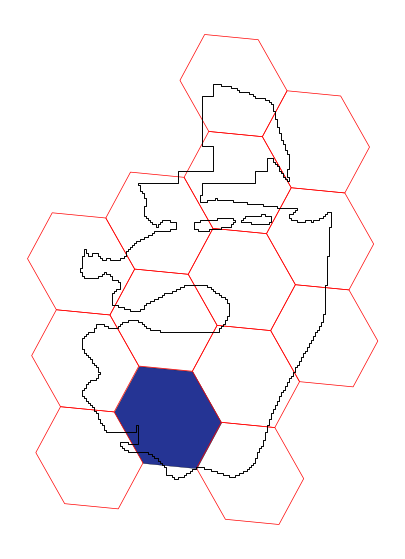

In [12]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo1_ivea7h.png', dpi=600)
plt.show()

#### Level 11

In [13]:
levels = [10, 11]
fix_thresholds = [0.95, 0.90]
min_threshold = 0.05
levels_areas_ivea7h = {l: dggal_utils.get_level_cell_area(dggs=ivea7h, level=l) for l in levels}

In [14]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas_ivea7h,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [15]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 2
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

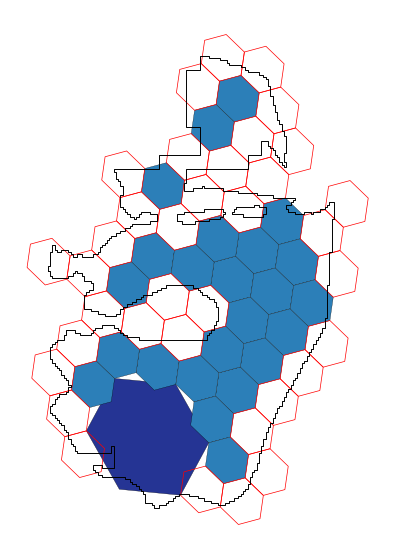

In [16]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo2_ivea7h.png', dpi=600)
plt.show()

#### Level 12

In [17]:
levels = [10, 11, 12]
fix_thresholds = [0.95, 0.90, 0.50]
min_threshold = 0.05
levels_areas_ivea7h = {l: dggal_utils.get_level_cell_area(dggs=ivea7h, level=l) for l in levels}

In [18]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas_ivea7h,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [19]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 2
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

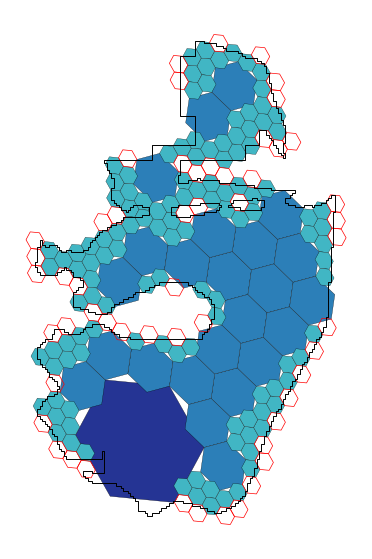

In [20]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo3_ivea7h.png', dpi=600)
plt.show()

#### rHealPix

In [21]:
level_color = {
    9: '#253494',
    10: '#2c7fb8',
    11: '#41b6c4',
}

In [22]:

dggs_name = 'rHEALPix'
dggs_instance = rhealpix3

#### Level 9

In [23]:
levels = [9]
fix_thresholds = [0.95]
min_threshold = 0.05
levels_areas = {l: rhealpix_utils.get_level_cell_area(dggs=dggs_instance, level=l) for l in levels}

In [24]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [25]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 1
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

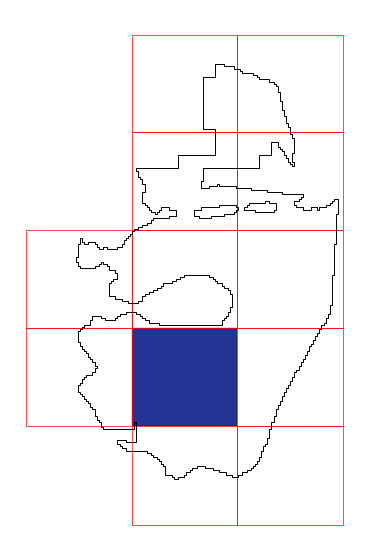

In [26]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo1_rhealpix.png', dpi=600)
plt.show()

#### Level 10

In [27]:
levels = [9, 10]
fix_thresholds = [0.95, 0.90]
min_threshold = 0.05
levels_areas = {l: rhealpix_utils.get_level_cell_area(dggs=dggs_instance, level=l) for l in levels}

In [28]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [29]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 1
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

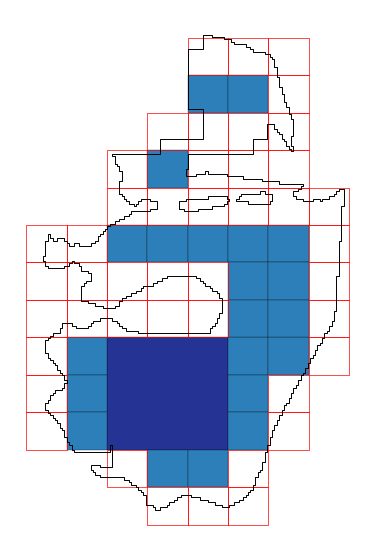

In [30]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo2_rhealpix.png', dpi=600)
plt.show()

#### Level 11

In [31]:
levels = [9, 10, 11]
fix_thresholds = [0.95, 0.90, 0.50]
min_threshold = 0.05
levels_areas = {l: rhealpix_utils.get_level_cell_area(dggs=dggs_instance, level=l) for l in levels}

In [32]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [33]:
fix_grid['level'] = fix_grid.cell_id.str.len() - 1
fix_grid['colors'] = fix_grid.level.map(lambda x: level_color[x])

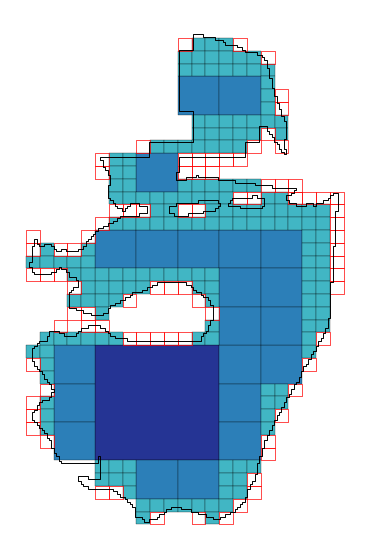

In [34]:
fig, ax = plt.subplots(ncols=1, figsize=(5, 7))
var_grid.boundary.plot(ax=ax, color='red', linewidth=0.5)
fix_grid.plot(color=fix_grid['colors'], ax=ax, edgecolor='black', linewidth=0.2)
roi.boundary.plot(ax=ax, linewidth=0.7, color='black')


ax.set_xticks([])
ax.set_yticks([])
ax.set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo3_rhealpix.png', dpi=600)
plt.show()

### Exemplos - thresholds

## P2H2

In [35]:
levels = [9, 10, 11]
fix_thresholds = [0.95, 0.90, 0.90]
min_threshold = 0.05
levels_areas = {l: rhealpix_utils.get_level_cell_area(dggs=dggs_instance, level=l) for l in levels}

In [36]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [37]:
plot_data = pd.concat([fix_grid, var_grid])
plot_data['level'] = plot_data.cell_id.str.len() - 1
plot_data['colors'] = plot_data.level.map(lambda x: level_color[x])

In [38]:
thresholds = [0.5, 0.6, 0.7]
ncols = len(thresholds)

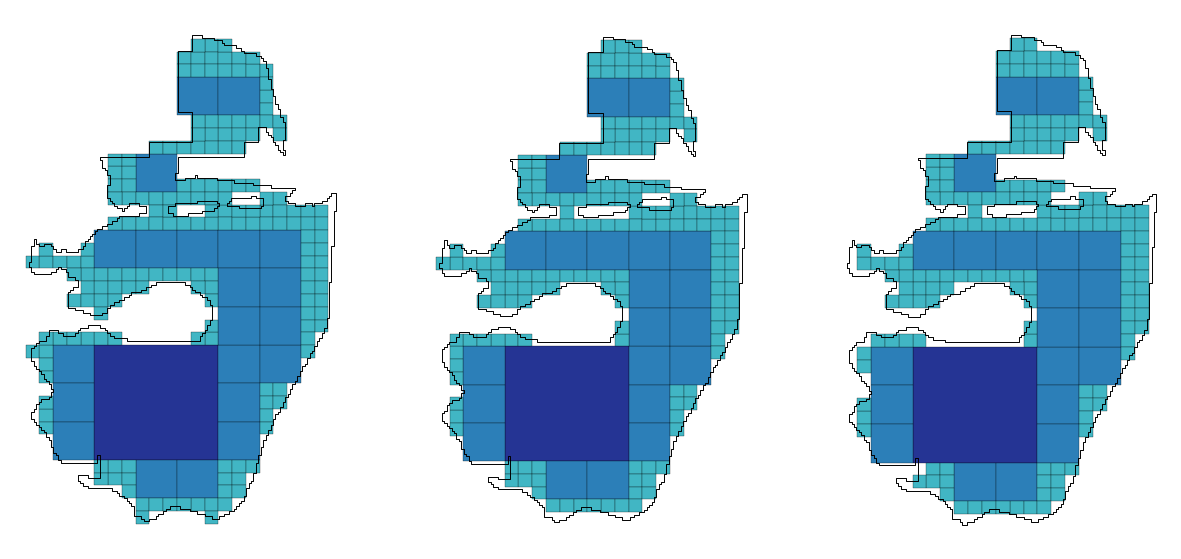

In [39]:
fig, ax = plt.subplots(ncols=ncols, figsize=(5 * ncols, 7))

for i, t in enumerate(thresholds):
    tmp_data = plot_data.loc[plot_data.prop > t]
    tmp_data.plot(color=tmp_data['colors'], ax=ax[i], edgecolor='black', linewidth=0.2)
    roi.boundary.plot(ax=ax[i], linewidth=0.7, color='black')


    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo3_rhealpix.png', dpi=600)
plt.show()

## P2H1

In [40]:
levels = [9, 10, 11]
fix_thresholds = [0.90, 0.80, 0.80]
min_threshold = 0.1
levels_areas = {l: rhealpix_utils.get_level_cell_area(dggs=dggs_instance, level=l) for l in levels}

In [41]:
fix_grid, var_grid = experiment.cover_geometry(
    dggs_name=dggs_name,
    dggs_instance=dggs_instance,
    geometry=geometry,
    levels=levels,
    levels_areas=levels_areas,
    fix_thresholds=fix_thresholds,
    min_threshold=min_threshold,
    return_only_fix_grid=False)

In [42]:
plot_data = pd.concat([fix_grid, var_grid])
plot_data['level'] = plot_data.cell_id.str.len() - 1
plot_data['colors'] = plot_data.level.map(lambda x: level_color[x])

In [43]:
thresholds = [0.5, 0.6, 0.7]
ncols = len(thresholds)

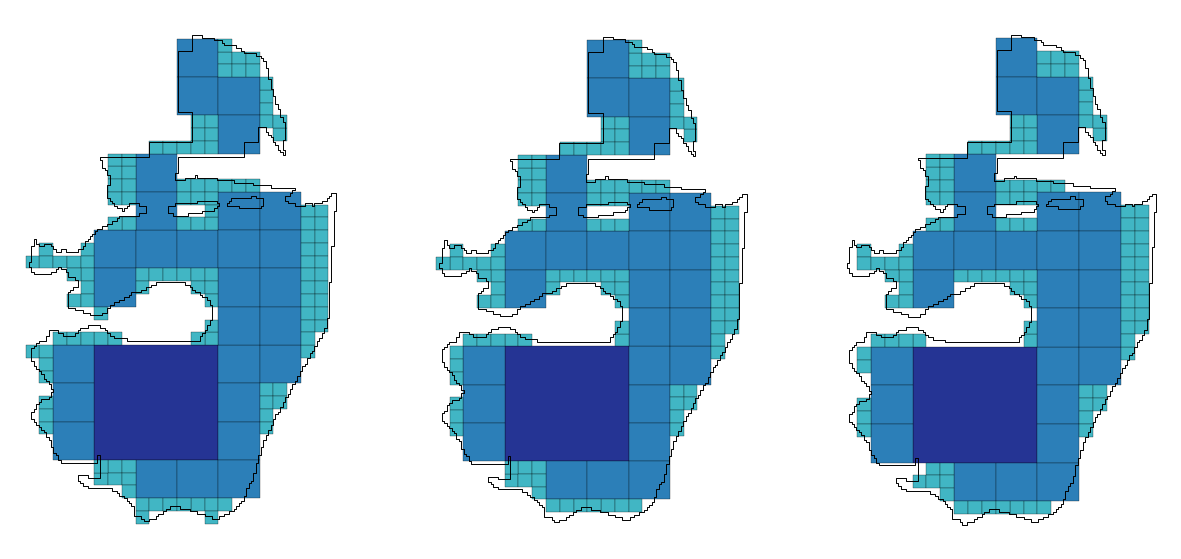

In [44]:
fig, ax = plt.subplots(ncols=ncols, figsize=(5 * ncols, 7))

for i, t in enumerate(thresholds):
    tmp_data = plot_data.loc[plot_data.prop > t]
    tmp_data.plot(color=tmp_data['colors'], ax=ax[i], edgecolor='black', linewidth=0.2)
    roi.boundary.plot(ax=ax[i], linewidth=0.7, color='black')


    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].set_axis_off()


# plt.savefig(f'{fig_output_folder}/exemplo3_rhealpix.png', dpi=600)
plt.show()